In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Ready!")


Ready!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [3]:
import os
print(os.getcwd())
print(os.listdir())

F:\aptitude\market-segmentation
['.ipynb_checkpoints', '01_data_cleaning.ipynb', '02_segmentation.ipynb', '03_forecasting.ipynb', 'data', 'online+retail+ii', 'online+retail+ii.zip', 'README.md.txt', 'visuals']


In [4]:
print(os.listdir('online+retail+ii'))

['online_retail_II.xlsx']


In [5]:
df = pd.read_excel('online+retail+ii/online_retail_II.xlsx', sheet_name='Year 2009-2010')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (525461, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print("Rows & Columns:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())

Rows & Columns: (525461, 8)

Column names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types:
 Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

Null values:
 Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [7]:

df.dropna(subset=['Customer ID'], inplace=True)


df = df[~df['Invoice'].astype(str).str.startswith('C')]


df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


df['Revenue'] = df['Quantity'] * df['Price']

print("Cleaned Shape:", df.shape)
print("Null values remaining:\n", df.isnull().sum())

Cleaned Shape: (407664, 9)
Null values remaining:
 Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64


In [8]:
df.to_csv('data/cleaned_retail.csv', index=False)
print("Saved successfully!")

Saved successfully!


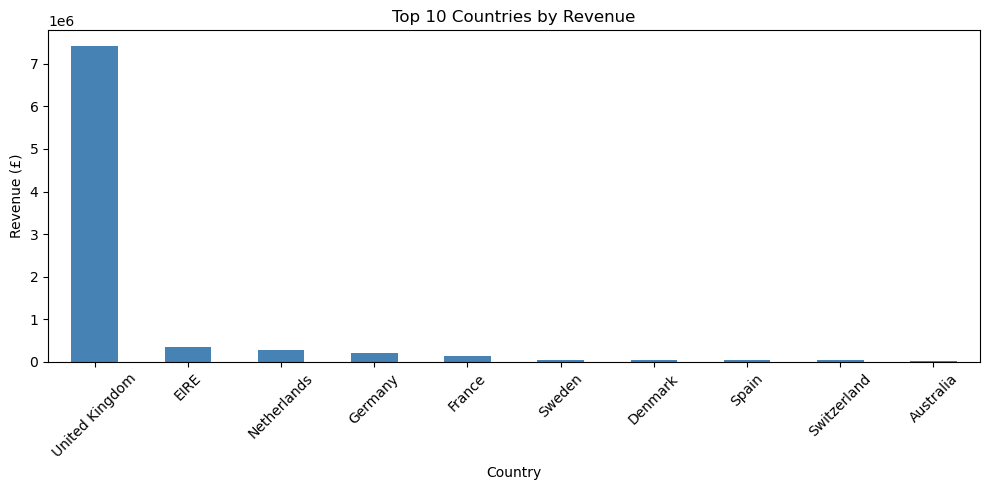

Chart 1 saved!


In [9]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/revenue_by_country.png', bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

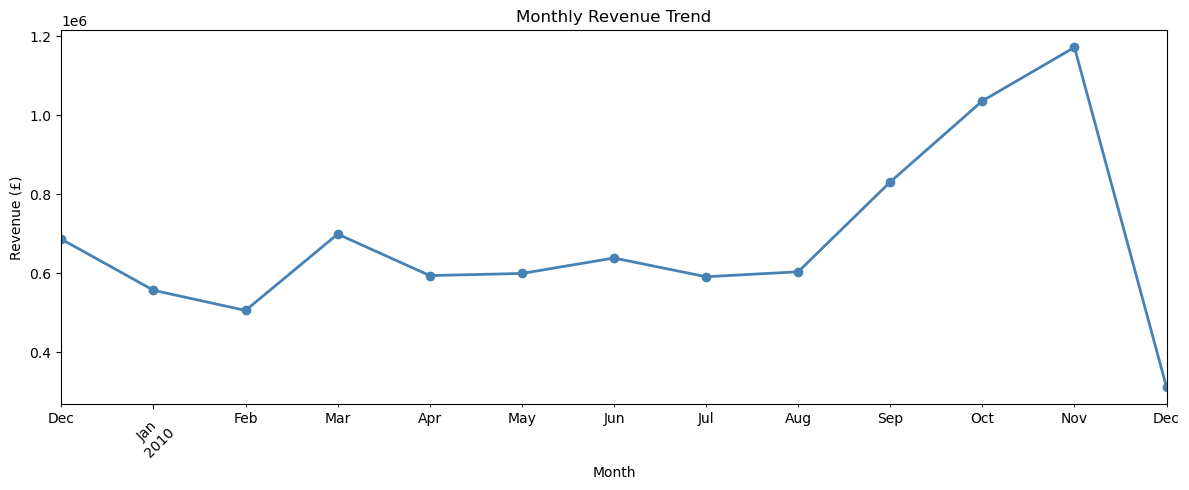

Chart 2 saved!


In [10]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', color='steelblue', linewidth=2, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/monthly_revenue.png', bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

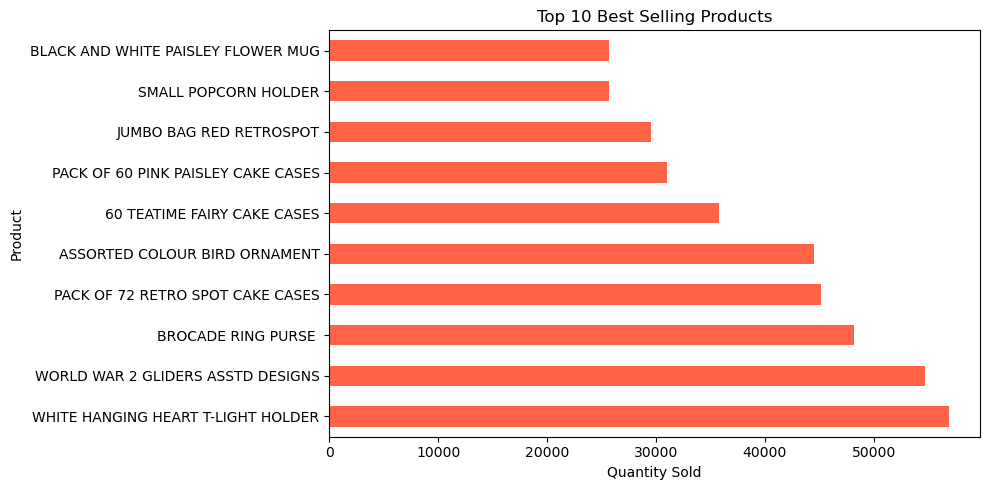

Chart 3 saved!


In [11]:
top_products = (df.groupby('Description')['Quantity']
                .sum()
                .sort_values(ascending=False)
                .head(10))

plt.figure(figsize=(10,5))
top_products.plot(kind='barh', color='tomato')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('visuals/top_products.png', bbox_inches='tight')
plt.show()
print("Chart 3 saved!")